### California Housing – modellering som beslutsunderlag

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [2]:
df = pd.read_csv('housing.csv')
df.describe()
print(df.shape)

(20640, 10)


In [3]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [4]:
threshold = df["median_house_value"].quantile(0.8)
df["high_value"] = (df["median_house_value"] >= threshold).astype(int)
X = df.drop(["median_house_value", "high_value"], axis=1)
y = df["high_value"]

feature_column_names = X.columns
target_column_name = "high_value"

X_full = X
y_full = y

print('X shape', X.shape)
print('y shape', y.shape)

print('\nKlassfördelning (hela datasetet):')
print(y.value_counts())

print('\nKlassfördelning i procent:')
print(y.value_counts(normalize= True))


X shape (20640, 9)
y shape (20640,)

Klassfördelning (hela datasetet):
high_value
0    16510
1     4130
Name: count, dtype: int64

Klassfördelning i procent:
high_value
0    0.799903
1    0.200097
Name: proportion, dtype: float64


In [5]:
print(feature_column_names)

print(target_column_name)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity'],
      dtype='str')
high_value


In [6]:
print('Saknade värden(Hela datasetet)')
print(X.isna().sum().sort_values(ascending=False))
# Kolumnen total_bedrooms har 207 saknade värden och det kommer jag hantera senare en median Imputer för att minska påverkan av extrema värden.
print(X.describe())

Saknade värden(Hela datasetet)
total_bedrooms        207
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  
count    20433.

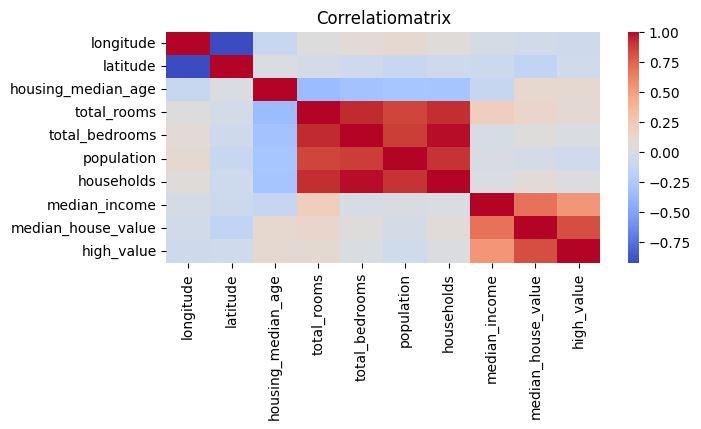

In [7]:
plt.figure(figsize=(7,3))
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm')
plt.title('Correlatiomatrix')
plt.show()

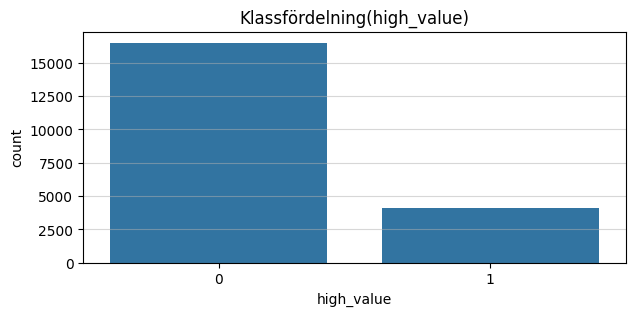

In [8]:
plt.figure(figsize=(7,3))
plt.title("Klassfördelning(high_value)")
sns.countplot(x=y)
plt.grid(axis="y", alpha= 0.5)
plt.show()


In [9]:
X_train, X_test, y_train, y_test = train_test_split( 
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, y_train.shape)
print("\nTrain positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())
print('\nKlassfördelning (TRAIN):')
print(y_train.value_counts())


(16512, 9) (16512,)

Train positive rate: 0.2000968992248062
Test positive rate: 0.2000968992248062

Klassfördelning (TRAIN):
high_value
0    13208
1     3304
Name: count, dtype: int64


In [10]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

C:\Users\janek\AppData\Local\Temp\ipykernel_11192\2836064378.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns


In [11]:
baseline = Pipeline([
    ('preprocessing',preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])
baseline_scores = cross_val_score(
    baseline,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Baseline F1:", baseline_scores.mean())

Baseline F1: 0.0


In [12]:
numeric_pipeline_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor_tree = ColumnTransformer([
    ('num', numeric_pipeline_tree, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [13]:

logreg_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

dt_pipeline = Pipeline([
    ('preprocessing', preprocessor_tree),
    ('model', DecisionTreeClassifier(random_state=42))
])

rf_pipeline = Pipeline([
    ('preprocessing', preprocessor_tree),
    ('model', RandomForestClassifier(random_state=42))
])


models = {
    'LogisticRegression': logreg_pipeline,
    'DecisionTree': dt_pipeline,
    'RandomForest': rf_pipeline

}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] ={ 
        "F1 Score": f1_score(y_test, y_pred),
        "Recall": recall_score(y_test,y_pred),
        "Precision":precision_score(y_test,y_pred),
        "Accuracy": accuracy_score(y_test,y_pred)

    }

results_df = pd.DataFrame.from_dict(results, orient='index')
results_df

,F1 Score,Recall,Precision,Accuracy
LogisticRegression,0.691307,0.611380,0.795276,0.890746
DecisionTree,0.703364,0.696126,0.710754,0.882510
RandomForest,0.761204,0.688862,0.850523,0.913517


In [14]:
cv = StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
cv_results = {}
for name, model in models.items():
    scores= cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1'
    )

    cv_results[name] = {
        'Mean F1': scores.mean().round(3),
        'Std F1': scores.std().round(3)
}

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df.sort_values('Mean F1', ascending=False)
display(cv_results_df)

,Mean F1,Std F1
LogisticRegression,0.696,0.002
DecisionTree,0.704,0.012
RandomForest,0.782,0.009


In [15]:
cv_results_df['Best Score'] = (
    cv_results_df['Mean F1'] - cv_results_df['Std F1']
)
best_model_name = cv_results_df['Best Score'].idxmax()
best_model = models[best_model_name]
best_model_name


'RandomForest'

In [17]:
param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 20],
    "model__min_samples_leaf": [1, 2],
    "model__min_samples_split": [2, 5],
    "model__max_features": ["sqrt", "log2"]
}
grid = GridSearchCV(
    best_model,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 20], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.

In [18]:

print('Best params', grid.best_params_)
print('Best CV score', grid.best_score_.round(3))

Best params {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 400}
Best CV score 0.783


In [19]:
res_rf = pd.DataFrame(grid.cv_results_)
res_rf.sort_values("rank_test_score").head(8)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__max_features,param_model__min_samples_leaf,param_model__min_samples_split,param_model__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
3,6.576700,0.520973,0.293080,0.024010,None,sqrt,1,5,400,"{'model__max_depth': None, 'model__max_feature...",0.796241,0.770318,0.783894,0.783484,0.010587,1
11,6.959969,0.143830,0.332092,0.004815,None,log2,1,5,400,"{'model__max_depth': None, 'model__max_feature...",0.796241,0.770318,0.783894,0.783484,0.010587,1
8,3.569520,0.067456,0.174370,0.005352,None,log2,1,2,200,"{'model__max_depth': None, 'model__max_feature...",0.797237,0.770005,0.782476,0.783239,0.011131,3
0,3.230286,0.198541,0.150331,0.015172,None,sqrt,1,2,200,"{'model__max_depth': None, 'model__max_feature...",0.797237,0.770005,0.782476,0.783239,0.011131,3
1,6.508797,0.382597,0.283618,0.029690,None,sqrt,1,2,400,"{'model__max_depth': None, 'model__max_feature...",0.789318,0.772773,0.784733,0.782274,0.006974,5
9,6.099715,0.105863,0.257443,0.014830,None,log2,1,2,400,"{'model__max_depth': None, 'model__max_feature...",0.789318,0.772773,0.784733,0.782274,0.006974,5
25,6.127344,0.105572,0.247000,0.004906,20,log2,1,2,400,"{'model__max_depth': 20, 'model__max_features'...",0.792846,0.773966,0.779919,0.782244,0.007881,7
17,6.510186,0.507423,0.280599,0.025716,20,sqrt,1,2,400,"{'model__max_depth': 20, 'model__max_features'...",0.792846,0.773966,0.779919,0.782244,0.007881,7



Classification report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      3302
           1       0.85      0.69      0.76       826

    accuracy                           0.91      4128
   macro avg       0.89      0.83      0.85      4128
weighted avg       0.91      0.91      0.91      4128



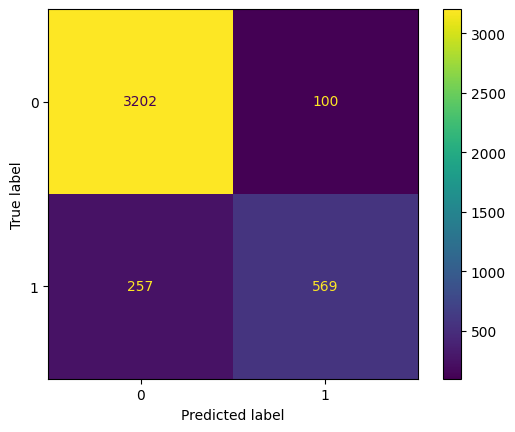

In [23]:
test_pred = best_model.predict(X_test)
display(ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test))
print("\nClassification report:\n", classification_report(y_test, test_pred))